# Phase 2: Exploratory Data Analysis (EDA)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

## 1. Load Data

In [11]:
interim_dir = Path("../data/interim")
data_path = interim_dir / "cleaned_data.parquet"

if not data_path.exists():
    data_path = Path("../data/processed/cleaned_data.parquet")

df = pd.read_parquet(data_path)
print(f"Loaded {len(df)} records.")
# Display sample
df.head()

Loaded 50258098 records.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0,8.350000
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2.550000
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0,1.950000
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0,5.566667
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0,3.533333


## 2. Temporal Distribution: Time Series Aggregation
Time series modeling requires data aggregated over a standard unit of time. We compare hourly vs daily demand patterns.

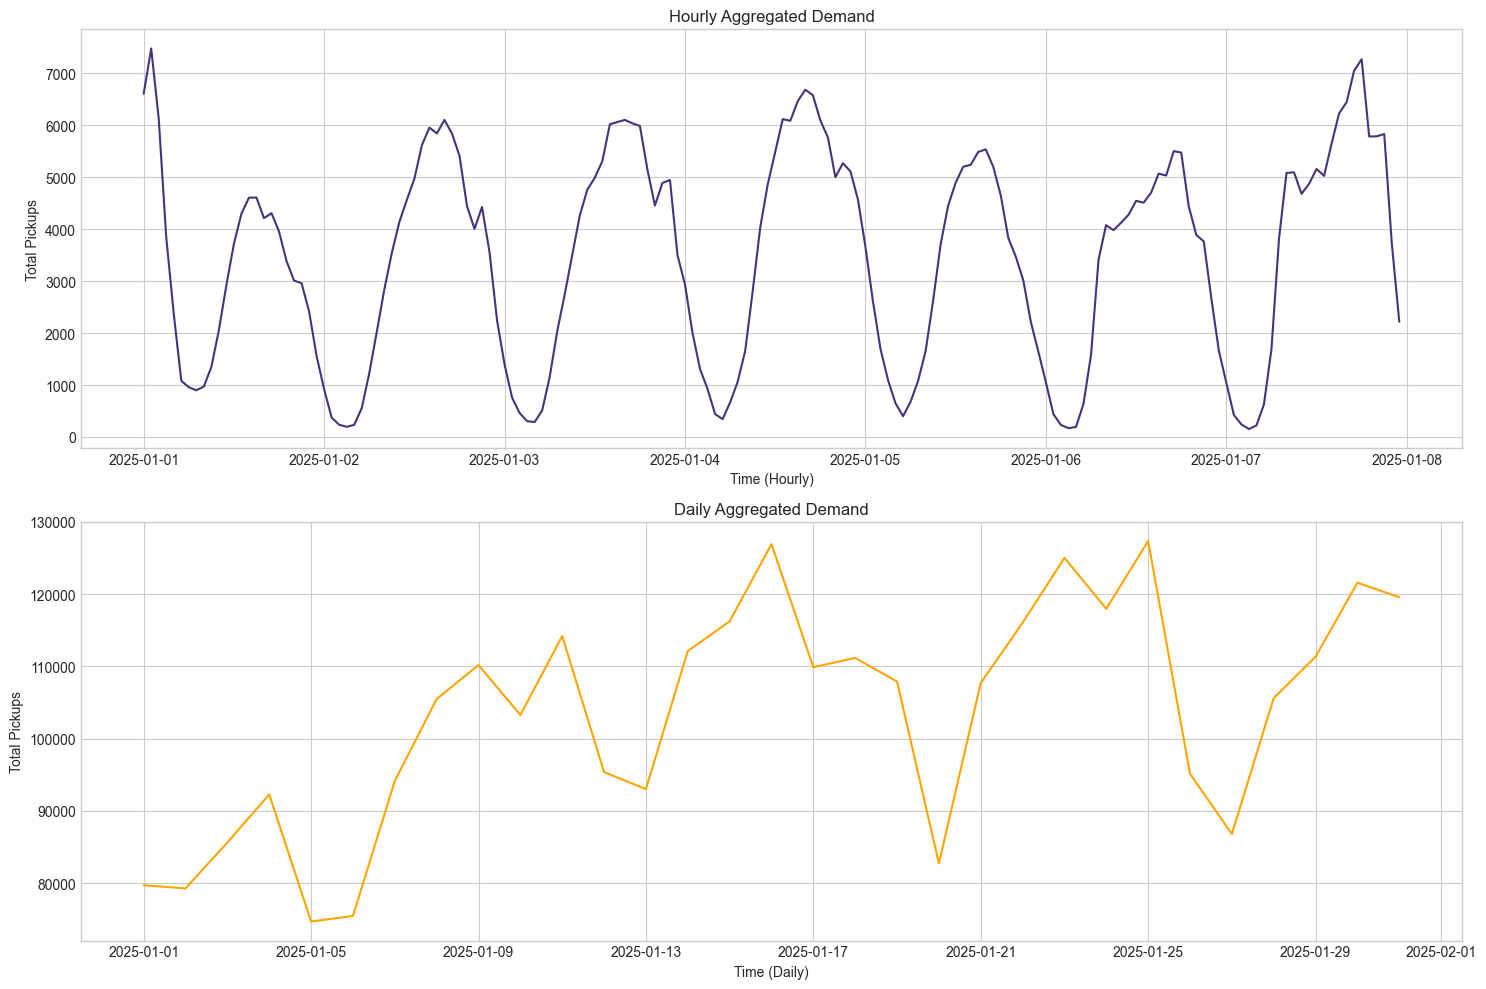

In [12]:
# Truncate to hours and days
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.floor('h')
df['pickup_day'] = df['tpep_pickup_datetime'].dt.floor('D')

# Aggregate demand
hourly_demand = df.groupby('pickup_hour').size().reset_index(name='demand')
daily_demand = df.groupby('pickup_day').size().reset_index(name='demand')

# Plot the aggregated demand
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

sns.lineplot(data=hourly_demand[:168], x='pickup_hour', y='demand', ax=axes[0])
axes[0].set_title('Hourly Aggregated Demand')
axes[0].set_xlabel('Time (Hourly)')
axes[0].set_ylabel('Total Pickups')

sns.lineplot(data=daily_demand[:31], x='pickup_day', y='demand', ax=axes[1], color='orange')
axes[1].set_title('Daily Aggregated Demand')
axes[1].set_xlabel('Time (Daily)')
axes[1].set_ylabel('Total Pickups')

plt.tight_layout()
plt.show()

## 3. Determine Aggregated Unit of Time
For the overall dataset, an **hourly** aggregation captures intraday seasonality well (e.g., morning and evening commutes),
whereas **daily** aggregation provides a smoother curve for long-term trends.

We will opt for an **hourly aggregated dataset** moving forward to preserve diurnal characteristics and potentially achieve a more nuanced forecast.

In [13]:
# We create the final base time series dataset (aggregated hourly)
base_ts = hourly_demand.rename(columns={'pickup_hour': 'timestamp', 'demand': 'total_demand'}).sort_values('timestamp')

# Set timestamp as index
base_ts.set_index('timestamp', inplace=True)

# Ensure there are no missing hours by resampling
base_ts = base_ts.resample('h').sum().fillna(0)

# Save the time series base table
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

base_ts_path = processed_dir / "base_hourly_demand.parquet"
base_ts.to_parquet(base_ts_path)

print(f"Saved aggregated hourly time series to {base_ts_path}")
base_ts.head()

Saved aggregated hourly time series to ..\data\processed\base_hourly_demand.parquet


,total_demand
timestamp,
2025-01-01 00:00:00,6610
2025-01-01 01:00:00,7481
2025-01-01 02:00:00,6126
2025-01-01 03:00:00,3840
2025-01-01 04:00:00,2369
